In [1]:
"""
v3_human_review.py
-------------------
A LangGraph pipeline that reads a free-format MT599 SWIFT settlement message
(which may contain one or more distinct instructions -- cancellations,
creations, amendments -- mixed together in plain text) and produces ONE
structured JSON output: a list of instructions, each tagged with its type
and validated against type-specific required fields.

This file is self-contained: schema, LLM setup, prompt, graph nodes, graph
build, visualization, and a test invocation demonstrating a full pause/
resume cycle. It does not depend on any other file.

Pipeline, in plain English:

    1. EXTRACT       -- one LLM call reads the whole message and returns
                        EVERY instruction found in it, as structured JSON
                        matching a fixed Pydantic schema.

    2. ROUTE         -- each extracted instruction is routed to a handler
                        based on its `type` (cancel / create / amend /
                        unidentified), using LangGraph's conditional edges.

    3. VALIDATE      -- each type-specific handler checks, in plain Python
                        (no LLM call), whether the fields required for THAT
                        type are present.

    4. LOOP          -- steps 2-3 repeat once per instruction, using an
                        index counter in the graph state, until every
                        instruction in the message has been routed and
                        validated.

    5. HUMAN REVIEW  -- NEW in this version. A required field missing from
                        the message text cannot be recovered by re-asking
                        the SAME LLM the SAME question -- the data simply
                        isn't there. So instead of an automated retry, the
                        graph PAUSES (via LangGraph's interrupt()) and hands
                        every incomplete instruction to a human, who may
                        know the missing value from somewhere OUTSIDE the
                        message (static account-reference data, a call to
                        the client, an internal lookup). Execution resumes
                        exactly where it paused once that input is supplied.
                        If nothing is missing, this step is skipped entirely
                        -- no pause on the happy path.

    6. FINALIZE      -- all processed instructions (now reflecting any
                        human-supplied corrections) are assembled into a
                        single JSON object: {"instructions": [...]}. This is
                        always the shape returned, whether the message had
                        one instruction, many, or none that could be
                        identified.
"""

import os
import json
import uuid
from enum import Enum
from typing import Optional, List, Dict, TypedDict

from pydantic import BaseModel, Field, ValidationError
from langchain_together import ChatTogether
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command


# ---------------------------------------------------------------------------
# 1. STRUCTURED OUTPUT SCHEMA
#    This is the contract between "whatever the LLM says" and "what our
#    downstream settlement system receives". Pydantic enforces this shape;
#    LangChain uses it to instruct/parse the LLM's structured response.
# ---------------------------------------------------------------------------

class InstructionType(str, Enum):
    """
    The ONE field the graph branches on, so it's constrained to a fixed set
    of values instead of free text. If the LLM could write "Cancellation"
    or "CANCEL" instead of "cancel", the router's string-matching logic
    below would silently break -- forcing an enum here makes that
    impossible.
    """
    cancel = "cancel"
    create = "create"
    amend = "amend"
    unidentified = "unidentified"  # used when no operation could be found


class Instruction(BaseModel):
    """
    One settlement instruction extracted from the message.

    Design decision: every field except `type` is a plain Optional[str].
    We deliberately do NOT try to cast qty to int or settlementDate to a
    date object here. Reasons:
      1. MT599 is free text -- dates/numbers can appear in inconsistent
         formats, and asking a small LLM to also normalize formats increases
         the chance of it silently getting the normalization wrong.
      2. The receiving settlement system already owns format validation
         against its own static/reference data -- duplicating that logic
         here would be redundant and a maintenance burden.
      3. Keeping types uniform (all str) keeps the Pydantic model, and the
         prompt asking the LLM to fill it, simple -- which matters when the
         LLM is a small instruct model, not a frontier reasoning model.
    """
    type: InstructionType = Field(
        description="The operation identified from the message text."
    )
    clientRef: Optional[str] = Field(
        default=None, description="Client reference for this instruction."
    )
    scRef: Optional[str] = Field(
        default=None, description="SC (settlement/system) reference, if present."
    )
    isin: Optional[str] = Field(
        default=None, description="ISIN of the security, if present."
    )
    qty: Optional[str] = Field(
        default=None, description="Quantity, captured exactly as written."
    )
    settlementDate: Optional[str] = Field(
        default=None, description="Settlement date, captured exactly as written."
    )
    sfkAccount: Optional[str] = Field(
        default=None, description="SFK account number, if present."
    )
    pset: Optional[str] = Field(
        default=None, description="Place of settlement, if present."
    )
    party: Optional[str] = Field(
        default=None, description="Party details, if present."
    )
    cpty: Optional[str] = Field(
        default=None, description="Counterparty details, if present."
    )
    remarks: Optional[str] = Field(
        default=None,
        description=(
            "Free-text notes explaining any problem with this instruction. "
            "Populated when type is 'unidentified' (explaining why nothing "
            "could be matched), or when a required field is missing (e.g. "
            "'Missing required fields: isin, qty'). Cleared automatically "
            "if a human later supplies the missing value during review."
        ),
    )


class ExtractionResult(BaseModel):
    """
    Top-level shape returned by this pipeline.

    Design decision: ALWAYS a list, even for a single instruction, and
    ALWAYS non-empty (minimum one entry -- an 'unidentified' placeholder if
    nothing else could be found). This means downstream consumers never
    need to handle "no instructions" as a separate shape from "one
    instruction" from "many instructions" -- one contract, always.
    """
    instructions: List[Instruction] = Field(
        description=(
            "One or more instructions found in the message. If nothing "
            "could be identified, return exactly one instruction with "
            "type='unidentified' and an explanation in remarks."
        )
    )



C:\Users\Pandiyan\anaconda3\envs\langchain\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from dotenv import load_dotenv
load_dotenv(".env")
# ---------------------------------------------------------------------------
# 2. LLM SETUP (Together AI via LangChain)
# ---------------------------------------------------------------------------

# Model choice rationale:
#   - Qwen2.5-7B-Instruct-Turbo is confirmed (via LangChain's own docs) to
#     work with ChatTogether's with_structured_output().
#   - It's small/cheap/fast -- good for learning the LangGraph plumbing.
#   - Swap to "Qwen/Qwen2.5-72B-Instruct-Turbo" (one string change) once you
#     want to stress-test with messier / longer MT599 text.
TOGETHER_MODEL = "Qwen/Qwen2.5-7B-Instruct-Turbo"

llm = ChatTogether(
    model=TOGETHER_MODEL,
    temperature=0,  # deterministic extraction -- we want repeatable JSON, not creative text
    together_api_key=os.getenv("TOGETHER_API_KEY"),
)

# method="json_schema" asks the model to emit JSON conforming to our Pydantic
# schema; LangChain sends the schema to Together, which compiles it into a
# constrained-decoding "grammar" and parses the validated response back into
# an ExtractionResult object. This is our PREFERRED mode when it works.
structured_llm_json_schema = llm.with_structured_output(ExtractionResult, method="json_schema")

# FALLBACK: Together AI's grammar compiler can intermittently reject certain
# schema shapes with "Input validation error: grammar is not valid: failed
# to compile grammar" -- a provider-side limitation that affects BOTH
# json_schema and function_calling modes equally, since Together implements
# both using the same grammar-constrained decoding engine under the hood.
# The only reliable way around a provider-side grammar-compiler issue is to
# stop asking Together to constrain the output at all. This fallback does
# NOT use with_structured_output() or send our schema to Together in any
# form -- it prompts the raw `llm` for plain text, then WE parse and
# validate that text ourselves with json.loads() and Pydantic.


def _manual_json_extract(prompt: str) -> ExtractionResult:
    """
    Ask the model for JSON via plain prompting (no schema sent to the
    provider), then parse and validate the response ourselves.
    Raises json.JSONDecodeError or pydantic.ValidationError on failure --
    both are caught by the retry loop in extract_instructions().
    """
    manual_prompt = (
        prompt
        + "\n\nRespond with ONLY a single valid JSON object -- no markdown "
        "code fences, no explanation, no text before or after the JSON. "
        'The JSON must have this exact top-level shape: {"instructions": [...]}, '
        "where each item in the list has the fields described above."
    )
    raw_text = llm.invoke(manual_prompt).content.strip()

    # Models sometimes wrap JSON in ```json ... ``` fences even when told
    # not to -- strip those defensively before parsing.
    if raw_text.startswith("```"):
        raw_text = raw_text.strip("`")
        if raw_text.lower().startswith("json"):
            raw_text = raw_text[4:]
        raw_text = raw_text.strip()

    data = json.loads(raw_text)                    # may raise json.JSONDecodeError
    return ExtractionResult.model_validate(data)    # may raise pydantic.ValidationError



In [5]:

# ---------------------------------------------------------------------------
# 3. PROMPT
# ---------------------------------------------------------------------------

EXTRACTION_PROMPT = """You are parsing a free-format MT599 SWIFT message used in trade settlement.

The message may contain ONE OR MORE distinct instructions (cancellation, creation, amendment),
mixed together in free text, in any order.

For EACH instruction you find, extract:
- type: cancel, create, amend, or unidentified
- clientRef, scRef, isin, qty, settlementDate, sfkAccount, pset, party, cpty
- remarks: only used to explain when type is "unidentified"

Rules:
1. Capture every field exactly as written in the message. Do NOT reformat dates,
   numbers, or reference codes.
2. If a field is not mentioned for an instruction, leave it null. Do not guess.
3. If you cannot identify ANY operation in the entire message, return exactly ONE
   instruction with type="unidentified" and a short explanation in remarks.
4. Return every instruction you find -- do not drop or merge separate instructions.

Message:
\"\"\"{message}\"\"\"
"""



In [7]:

# ---------------------------------------------------------------------------
# 4. REQUIRED FIELDS PER TYPE
#    A single shared lookup table, used by BOTH the type-specific handler
#    nodes (section 7) and the human_review node (section 9). Pulling this
#    out once means the business rule for "what counts as complete" is
#    defined in exactly one place, not duplicated across nodes.
#
#    Business rules:
#      - cancel: only needs enough info to IDENTIFY which trade -- clientRef.
#      - create: booking a brand-new trade needs enough detail to actually
#        book it: clientRef, isin, qty, sfkAccount.
#      - amend: modifying an EXISTING trade only needs clientRef to identify
#        WHICH trade -- whatever field is being changed is whatever the
#        message mentions; nothing else is mandatory.
#      - unidentified: nothing to validate -- there's no operation to check
#        fields against.
# ---------------------------------------------------------------------------

REQUIRED_FIELDS_BY_TYPE: Dict[InstructionType, List[str]] = {
    InstructionType.cancel: ["clientRef"],
    InstructionType.create: ["clientRef", "isin", "qty", "sfkAccount"],
    InstructionType.amend: ["clientRef"],
    InstructionType.unidentified: [],
}


def _missing_fields(instruction: Instruction, required: List[str]) -> List[str]:
    """
    Given a list of field names that MUST be present for this instruction's
    type, return the subset that are actually missing (None or blank).
    Uses getattr() to read fields dynamically by name, so the SAME function
    works for every type's (different) required-field list.
    """
    missing = []
    for field_name in required:
        value = getattr(instruction, field_name)
        if value is None or str(value).strip() == "":
            missing.append(field_name)
    return missing



In [9]:

# ---------------------------------------------------------------------------
# 5. GRAPH STATE
#    current_index and processed_instructions exist purely to support
#    looping over a list one item at a time: LangGraph re-invokes nodes on
#    each pass through the graph (rather than looping inside one Python
#    function), so the "loop counter" has to live in the shared state
#    instead of a local variable.
# ---------------------------------------------------------------------------

class SettlementState(TypedDict):
    raw_message: str  # input: the MT599 free text

    all_instructions: List[Instruction]
    # The full list returned by extraction. This list itself does NOT change
    # during the loop -- we only ever read from it. Think of it as the
    # "source" list we're iterating over.

    current_index: int
    # Points at whichever instruction in all_instructions is currently being
    # routed/handled. Starts at 0, incremented by 1 inside each handler node
    # (see _advance() below) -- plays the same role as a plain
    # `for i in range(...)` loop counter, except expressed as graph state
    # because the "loop" here is graph edges, not a Python for-loop.

    processed_instructions: List[Instruction]
    # Starts empty. Each handler node appends exactly one (possibly
    # annotated) instruction here before advancing current_index. By the
    # time the loop finishes, this list has the same length as
    # all_instructions. The human_review node (section 9) may later modify
    # entries in this SAME list in place, before finalize packages it up.

    result: Optional[ExtractionResult]  # final output
    error: Optional[str]                # extraction-level error, if any



In [11]:

# ---------------------------------------------------------------------------
# 6. NODE: extract_instructions
#    One LLM call reads the entire message and returns every instruction it
#    can find, as a single structured response. Includes a retry that
#    SWITCHES STRATEGY between attempts rather than repeating the identical
#    call: attempt 1 uses Together's structured-output feature (json_schema
#    mode); attempt 2 bypasses it entirely with manual prompt-and-parse.
# ---------------------------------------------------------------------------

MAX_ATTEMPTS = 2  # attempt 1: json_schema (provider-side structured output).
                   # attempt 2: manual prompt-and-parse (no provider schema dependency).


def extract_instructions(state: SettlementState) -> SettlementState:
    message = state["raw_message"]
    last_error: Optional[str] = None

    for attempt in range(1, MAX_ATTEMPTS + 1):
        prompt = EXTRACTION_PROMPT.format(message=message)

        # On a retry, tell the model exactly what went wrong last time.
        if last_error:
            prompt += (
                f"\n\nYour previous response was invalid: {last_error}\n"
                "Please correct it and return valid JSON matching the schema."
            )

        try:
            if attempt == 1:
                # Preferred path: let Together's structured-output feature
                # constrain and validate the response for us.
                result = structured_llm_json_schema.invoke(prompt)
            else:
                # Fallback path: no schema sent to the provider at all --
                # we parse and validate the plain-text response ourselves.
                result = _manual_json_extract(prompt)

            state["all_instructions"] = result.instructions
            state["error"] = None
            break  # success -- stop retrying
        except ValidationError as ve:
            # Model's JSON didn't match our Pydantic schema (e.g. bad enum
            # value, missing required key) -- remember why, then retry.
            last_error = str(ve)
        except json.JSONDecodeError as je:
            # Only possible on the manual-parse path -- the model's text
            # response wasn't valid JSON at all.
            last_error = f"Response was not valid JSON: {je}"
        except Exception as e:
            # Covers provider-side errors like Together's "failed to
            # compile grammar" (a 422 from their API on the json_schema
            # path) -- record it and let the next attempt use the manual
            # fallback instead.
            last_error = str(e)
    else:
        # for/else: this branch runs only if the loop finished WITHOUT
        # hitting `break`, i.e. every attempt failed. Fall back to a single
        # 'unidentified' instruction so the router/loop below always has a
        # valid, non-empty list to work with -- it never has to special-case
        # "extraction failed entirely" as a different shape.
        state["all_instructions"] = [
            Instruction(
                type=InstructionType.unidentified,
                remarks=f"Extraction failed after {MAX_ATTEMPTS} attempts: {last_error}",
            )
        ]
        state["error"] = last_error

    # Initialize the loop state -- we're about to walk through
    # all_instructions one at a time, starting at index 0, with nothing
    # processed yet.
    state["current_index"] = 0
    state["processed_instructions"] = []
    return state



In [13]:

# ---------------------------------------------------------------------------
# 7. ROUTER NODE + TYPE-SPECIFIC HANDLERS
#    router is a "pass-through" node: it doesn't transform state at all, it
#    exists only so add_conditional_edges() has a named node to attach the
#    routing decision function to.
#
#    Each handler follows the same pattern:
#      a. look up the instruction current_index is pointing at
#      b. check its required fields using plain Python (no LLM call --
#         this is deliberately cheap and deterministic)
#      c. if anything required is missing, note it in `remarks`
#      d. append the (possibly annotated) instruction to
#         processed_instructions and move current_index forward by 1
# ---------------------------------------------------------------------------

def router(state: SettlementState) -> SettlementState:
    # Intentionally does nothing -- just returns state unchanged.
    return state


def route_by_type(state: SettlementState) -> str:
    """
    Decision function attached to the router's conditional edges. Looks at
    whichever instruction current_index is pointing at right now -- NOT the
    whole list -- because we're routing one instruction per pass through
    the graph.
    """
    current = state["all_instructions"][state["current_index"]]
    return current.type.value  # "cancel" | "create" | "amend" | "unidentified"


def _append_missing_note(instruction: Instruction, missing: List[str]) -> Instruction:
    """
    Write a "Missing required fields: x, y" note into `remarks`. Appends
    rather than overwrites (using a semicolon separator) so an existing
    remark is never silently erased. If nothing is missing, the instruction
    is returned untouched.
    """
    if not missing:
        return instruction
    note = f"Missing required fields: {', '.join(missing)}"
    instruction.remarks = f"{instruction.remarks}; {note}" if instruction.remarks else note
    return instruction


def _advance(state: SettlementState, instruction: Instruction) -> SettlementState:
    """
    Shared bookkeeping used by every handler after it finishes with the
    current instruction: record it into the output list, then move the
    loop pointer forward so route_by_type() looks at the NEXT instruction
    on the following pass through the graph.
    """
    state["processed_instructions"].append(instruction)
    state["current_index"] += 1
    return state


def handle_cancel(state: SettlementState) -> SettlementState:
    current = state["all_instructions"][state["current_index"]]
    missing = _missing_fields(current, REQUIRED_FIELDS_BY_TYPE[InstructionType.cancel])
    current = _append_missing_note(current, missing)
    return _advance(state, current)


def handle_create_or_amend(state: SettlementState) -> SettlementState:
    """
    Handles BOTH create and amend, since they're routed to the same node
    (see the conditional_edges mapping in section 10) -- each type has a
    different required-field list (see REQUIRED_FIELDS_BY_TYPE), looked up
    by the instruction's own `type`, so no separate node is needed per type.
    """
    current = state["all_instructions"][state["current_index"]]
    missing = _missing_fields(current, REQUIRED_FIELDS_BY_TYPE[current.type])
    current = _append_missing_note(current, missing)
    return _advance(state, current)


def handle_unidentified(state: SettlementState) -> SettlementState:
    """
    Nothing to validate here -- the extraction node already explained WHY
    this instruction is unidentified, in `remarks`. Pass through and
    advance the loop pointer, same as every other handler.
    """
    current = state["all_instructions"][state["current_index"]]
    return _advance(state, current)


def has_more_instructions(state: SettlementState) -> str:
    """
    Decision function attached AFTER every handler node. Checks whether
    current_index has reached the end of all_instructions:
      - if NOT yet at the end -> route back to `router` to process the
        NEXT instruction (the "loop again" branch)
      - if we've processed everything -> move on to human_review
    """
    if state["current_index"] < len(state["all_instructions"]):
        return "loop"
    return "done"


In [15]:

# ---------------------------------------------------------------------------
# 8. NODE: human_review
#    NEW in this version. Runs once, after every instruction has been
#    routed and validated. Looks for instructions still missing required
#    fields, and -- ONLY if there are any -- pauses the graph with
#    interrupt(), handing a human the exact list of what's missing.
#
#    Why a human instead of another LLM retry: the missing values were
#    never in the original message text in the first place, so re-asking
#    the same model the same question about the same text cannot produce
#    new information. A human, on the other hand, may be able to supply
#    the value from somewhere the message never covered -- e.g. a static
#    account-reference lookup, or a phone call to the client. This node
#    models exactly that hand-off.
#
#    IMPORTANT (LangGraph behaviour): when a graph resumes after an
#    interrupt, the node RE-RUNS FROM THE TOP -- everything before the
#    interrupt() call executes again. That's safe here because the
#    "find what's missing" logic above is pure computation with no side
#    effects. It would NOT be safe to put something like "send an email"
#    before interrupt() in the same node, since that would fire twice.
# ---------------------------------------------------------------------------

def human_review(state: SettlementState) -> SettlementState:
    # Step 1: find every instruction still missing something required.
    # This re-runs on resume, which is fine -- it's pure computation.
    incomplete = []
    for index, instruction in enumerate(state["processed_instructions"]):
        required = REQUIRED_FIELDS_BY_TYPE.get(instruction.type, [])
        missing = _missing_fields(instruction, required)
        if missing:
            incomplete.append({
                "index": index,
                "clientRef": instruction.clientRef,
                "type": instruction.type.value,
                "missing_fields": missing,
            })

    if not incomplete:
        # Nothing to review -- skip the pause entirely on the happy path.
        return state

    # Step 2: pause here and hand the incomplete list to a human. The
    # payload must be JSON-serializable -- it's what gets surfaced to
    # whoever/whatever resumes this graph (a script, an internal review
    # UI, etc.).
    human_updates = interrupt({
        "message": (
            "The following instructions are missing required fields that "
            "were NOT present in the original MT599 message text. Supply "
            "values only if known from another source (e.g. static account "
            "reference data, a call to the client) -- otherwise leave "
            "unresolved."
        ),
        "items": incomplete,
    })
    # Expected shape of human_updates once supplied via Command(resume=...):
    #   { "0": {"sfkAccount": "5678"} }
    # keyed by the same "index" values listed in `incomplete` above, each
    # mapping to a dict of field_name -> corrected_value.

    if human_updates:
        for index_str, field_updates in human_updates.items():
            instruction = state["processed_instructions"][int(index_str)]
            for field_name, value in field_updates.items():
                setattr(instruction, field_name, value)

    # Step 3: re-check every instruction that was flagged, now that
    # corrections (if any) have been applied, and refresh its `remarks`
    # accordingly -- cleared if now complete, or an accurate up-to-date
    # note if something is still genuinely unavailable.
    for item in incomplete:
        instruction = state["processed_instructions"][item["index"]]
        required = REQUIRED_FIELDS_BY_TYPE.get(instruction.type, [])
        still_missing = _missing_fields(instruction, required)
        instruction.remarks = (
            f"Missing required fields: {', '.join(still_missing)}"
            if still_missing else None
        )

    return state


In [17]:


# ---------------------------------------------------------------------------
# 9. NODE: finalize
#    By this point, processed_instructions reflects every instruction from
#    all_instructions, validated and (if applicable) corrected during human
#    review. This node's only job is to package that list into the fixed
#    ExtractionResult shape defined in section 1.
# ---------------------------------------------------------------------------

def finalize(state: SettlementState) -> SettlementState:
    state["result"] = ExtractionResult(instructions=state["processed_instructions"])
    return state



In [19]:

# ---------------------------------------------------------------------------
# 10. BUILD THE GRAPH
#     Structure, in plain English:
#       extract_instructions -> router
#       router --(route_by_type)--> handle_cancel | handle_create_or_amend | handle_unidentified
#       each handler --(has_more_instructions)--> router (loop) | human_review (done looping)
#       human_review -> finalize
#
#     A checkpointer is REQUIRED for interrupt()/Command(resume=...) to
#     work -- LangGraph needs somewhere to persist the paused state. We use
#     InMemorySaver here (fine for learning/local dev); production systems
#     use a durable checkpointer (e.g. backed by Postgres or SQLite) so a
#     paused thread survives a process restart.
# ---------------------------------------------------------------------------

builder = StateGraph(SettlementState)

builder.add_node("extract_instructions", extract_instructions)
builder.add_node("router", router)
builder.add_node("handle_cancel", handle_cancel)
builder.add_node("handle_create_or_amend", handle_create_or_amend)
builder.add_node("handle_unidentified", handle_unidentified)
builder.add_node("human_review", human_review)
builder.add_node("finalize", finalize)

builder.set_entry_point("extract_instructions")
builder.add_edge("extract_instructions", "router")

builder.add_conditional_edges("router", route_by_type, {
    "cancel": "handle_cancel",
    "create": "handle_create_or_amend",
    "amend": "handle_create_or_amend",
    "unidentified": "handle_unidentified",
})

for handler_node in ["handle_cancel", "handle_create_or_amend", "handle_unidentified"]:
    builder.add_conditional_edges(handler_node, has_more_instructions, {
        "loop": "router",          # more instructions left -- process the next one
        "done": "human_review",    # nothing left -- move on to the review step
    })

builder.add_edge("human_review", "finalize")
builder.set_finish_point("finalize")

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)


In [21]:

# ---------------------------------------------------------------------------
# 11. VISUALIZE THE GRAPH
#     Renders inline if running inside Jupyter/IPython; otherwise saves a
#     PNG to disk, since there's no notebook cell to render into.
# ---------------------------------------------------------------------------

def visualize_graph(compiled_graph, output_path: str = "graph_v3.png") -> None:
    try:
        png_bytes = compiled_graph.get_graph().draw_mermaid_png()
    except Exception as e:
        print(f"Graph visualization failed (mermaid/graphviz dependency issue?): {e}")
        return

    try:
        from IPython.display import Image, display
        from IPython import get_ipython
        if get_ipython() is not None:
            display(Image(png_bytes))
            return
    except ImportError:
        pass

    with open(output_path, "wb") as f:
        f.write(png_bytes)
    print(f"Graph diagram saved to: {output_path}")



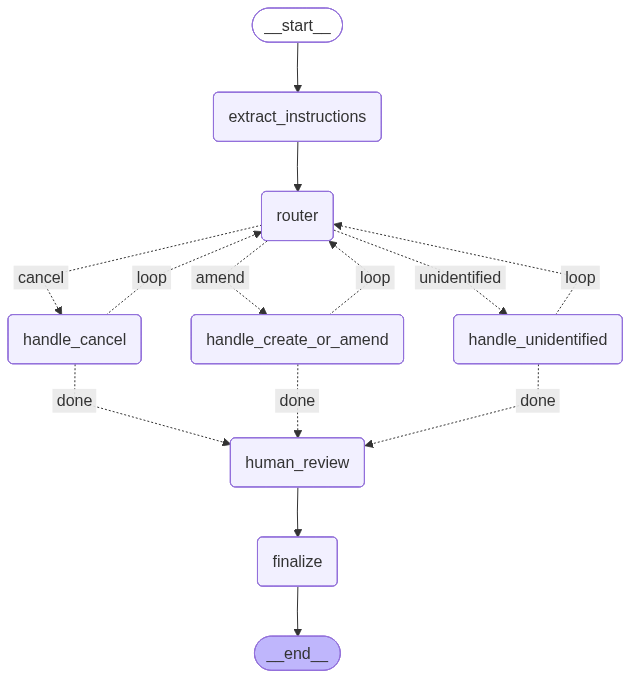

Deserializing unregistered type __main__.InstructionType from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'InstructionType')]
Deserializing unregistered type __main__.Instruction from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Instruction')]



--- Graph paused for human review ---
{
  "message": "The following instructions are missing required fields that were NOT present in the original MT599 message text. Supply values only if known from another source (e.g. static account reference data, a call to the client) -- otherwise leave unresolved.",
  "items": [
    {
      "index": 1,
      "clientRef": "QWERTY",
      "type": "create",
      "missing_fields": [
        "sfkAccount"
      ]
    }
  ]
}

--- Final result ---
{
  "instructions": [
    {
      "type": "cancel",
      "clientRef": "XYZABC",
      "scRef": null,
      "isin": null,
      "qty": null,
      "settlementDate": null,
      "sfkAccount": null,
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    },
    {
      "type": "create",
      "clientRef": "QWERTY",
      "scRef": null,
      "isin": "DFGHISIN",
      "qty": "100",
      "settlementDate": null,
      "sfkAccount": "5678",
      "pset": null,
      "party": null,
 

In [23]:

# ---------------------------------------------------------------------------
# 12. QUICK TEST -- demonstrates a full pause/resume cycle
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    visualize_graph(graph)

    # Deliberately missing SFK Account for the create instruction, so we
    # exercise the human_review pause -- this is the case that COULDN'T be
    # resolved by re-extracting from the message, since the account number
    # was simply never mentioned.
    sample_message = (
        "Please cancel the trade has client reference XYZABC, "
        "Also create a new trade with client reference QWERTY, "
        "it should have the ISIN DFGHISIN, Qty=100. "
        "Also amend trade with client reference AMEND001, change settlement date to 5th July."
    )

    # Every paused/resumed run needs a thread_id -- it's the key LangGraph
    # uses to look up the persisted (paused) state when we resume later.
    config = {"configurable": {"thread_id": str(uuid.uuid4())}}

    initial_state = {
        "raw_message": sample_message,
        "all_instructions": [],
        "current_index": 0,
        "processed_instructions": [],
        "result": None,
        "error": None,
    }

    # First call: runs until either finalize (nothing was missing) or a
    # pause at human_review (something was missing).
    first_pass = graph.invoke(initial_state, config)

    if "__interrupt__" in first_pass:
        print("\n--- Graph paused for human review ---")
        interrupt_payload = first_pass["__interrupt__"][0].value
        print(json.dumps(interrupt_payload, indent=2))

        # In a real system, this is where a person (or an internal review
        # UI/API) supplies corrections looked up from elsewhere -- NOT by
        # re-reading the original message, since the data was never there.
        # Here we hardcode a resume value as a demonstration: suppose the
        # SFK account for QWERTY was found in static account-reference data.
        human_supplied_updates = {
            "1": {"sfkAccount": "5678"}  # index 1 = the create instruction
        }

        final_state = graph.invoke(Command(resume=human_supplied_updates), config)
    else:
        # Nothing was missing -- the graph ran straight through to finalize.
        final_state = first_pass

    print("\n--- Final result ---")
    print(json.dumps(final_state["result"].model_dump(), indent=2))


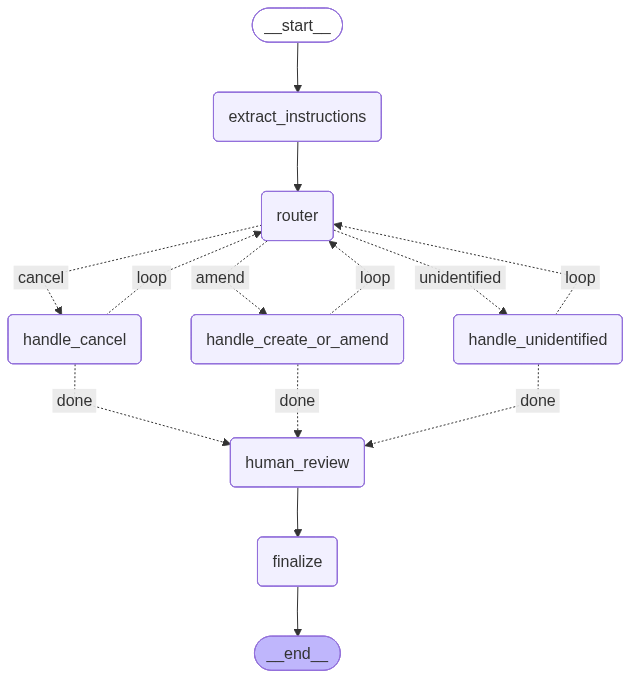


--- Graph paused for human review ---
The following instructions are missing required fields that were NOT present in the original MT599 message text. Supply values only if known from another source (e.g. static account reference data, a call to the client) -- otherwise leave unresolved.

Instruction #1 (type=create, clientRef=QWERTY) is missing: sfkAccount


  Enter value for 'sfkAccount' (or press Enter to skip):  9076



--- Final result ---
{
  "instructions": [
    {
      "type": "cancel",
      "clientRef": "XYZABC",
      "scRef": null,
      "isin": null,
      "qty": null,
      "settlementDate": null,
      "sfkAccount": null,
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    },
    {
      "type": "create",
      "clientRef": "QWERTY",
      "scRef": null,
      "isin": "DFGHISIN",
      "qty": "100",
      "settlementDate": null,
      "sfkAccount": "9076",
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    },
    {
      "type": "amend",
      "clientRef": "AMEND001",
      "scRef": null,
      "isin": null,
      "qty": null,
      "settlementDate": "5th July",
      "sfkAccount": null,
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    }
  ]
}


In [25]:
# ---------------------------------------------------------------------------
# 12. QUICK TEST -- demonstrates a full pause/resume cycle
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    visualize_graph(graph)

    # Deliberately missing SFK Account for the create instruction, so we
    # exercise the human_review pause -- this is the case that COULDN'T be
    # resolved by re-extracting from the message, since the account number
    # was simply never mentioned.
    sample_message = (
        "Please cancel the trade has client reference XYZABC, "
        "Also create a new trade with client reference QWERTY, "
        "it should have the ISIN DFGHISIN, Qty=100. "
        "Also amend trade with client reference AMEND001, change settlement date to 5th July."
    )

    # Every paused/resumed run needs a thread_id -- it's the key LangGraph
    # uses to look up the persisted (paused) state when we resume later.
    config = {"configurable": {"thread_id": str(uuid.uuid4())}}

    initial_state = {
        "raw_message": sample_message,
        "all_instructions": [],
        "current_index": 0,
        "processed_instructions": [],
        "result": None,
        "error": None,
    }

    # First call: runs until either finalize (nothing was missing) or a
    # pause at human_review (something was missing).
    first_pass = graph.invoke(initial_state, config)

    if "__interrupt__" in first_pass:
        print("\n--- Graph paused for human review ---")
        interrupt_payload = first_pass["__interrupt__"][0].value
        print(interrupt_payload["message"])

        # Build the resume dict interactively -- for each incomplete
        # instruction, ask a real question at the terminal for each missing
        # field, and only include an answer if the person actually typed
        # something (an empty Enter means "still unavailable, leave it").
        human_supplied_updates: dict = {}
        for item in interrupt_payload["items"]:
            index = str(item["index"])
            print(
                f"\nInstruction #{item['index']} "
                f"(type={item['type']}, clientRef={item['clientRef']}) "
                f"is missing: {', '.join(item['missing_fields'])}"
            )
            field_updates = {}
            for field_name in item["missing_fields"]:
                value = input(f"  Enter value for '{field_name}' (or press Enter to skip): ").strip()
                if value:
                    field_updates[field_name] = value
            if field_updates:
                human_supplied_updates[index] = field_updates

        final_state = graph.invoke(Command(resume=human_supplied_updates), config)
    else:
        # Nothing was missing -- the graph ran straight through to finalize.
        final_state = first_pass

    print("\n--- Final result ---")
    print(json.dumps(final_state["result"].model_dump(), indent=2))
